In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import pennylane as qml
from pennylane.qnn import TorchLayer

# ─────────────────────────────────────────────────────────────────────
# WHAT CHANGED FROM v2 AND WHY
# ─────────────────────────────────────────────────────────────────────
#
#  PROBLEM: Train=99.9% vs Val=92.7% → 7.2% overfitting gap
#  CAUSE:   716K-param backbone memorizes GAN-balanced training data
#
#  FIX STRATEGY: Shrink & regularise backbone so it CAN'T memorise.
#  Force the quantum layer to do more discriminative work.
#
#  Key changes:
#  1. Backbone channels:   32→64→128  becomes  16→32→64   (-75% params)
#  2. MixUp regularisation on training batches (no domain knowledge needed)
#  3. Quantum: n_qubits=8, q_depth=6, 3-axis measurement (kept from v2)
#  4. Stronger bridge dropout: 0.2 → 0.35
#  5. Backbone dropout: 0.15 → 0.20
#  6. Stochastic depth rates increased: 0.05/0.10/0.15 → 0.10/0.15/0.20
#  7. Label smoothing: 0.1 → 0.15
#  8. Weight decay: 1e-4 → 3e-4
#  9. SAM (Sharpness-Aware Minimisation) optimizer wrapper
#     → finds flatter minima → better generalisation
# ─────────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────
# SEEDING
# ─────────────────────────────────────────────
def seed_all(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
n_qubits     = 8
q_depth      = 6
q_out_dim    = 3 * n_qubits    # 24 features from 3-axis Pauli measurement
batch_size   = 32
num_classes  = 10
num_epochs   = 80
lr           = 0.0005
weight_decay = 3e-4             # ↑ from 1e-4 — stronger L2 penalty

# ─────────────────────────────────────────────
# TRANSFORMS
# ─────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ─────────────────────────────────────────────
# DATASETS & LOADERS
# ─────────────────────────────────────────────
TRAIN_PATH = 'virus_MNIST dataset/train'
TEST_PATH  = 'virus_MNIST dataset/test'
VAL_PATH   = 'virus_MNIST dataset/val'

try:
    train_dataset = ImageFolder(TRAIN_PATH, transform=train_transform)
    test_dataset  = ImageFolder(TEST_PATH,  transform=eval_transform)
    val_dataset   = ImageFolder(VAL_PATH,   transform=eval_transform)
    print("Datasets loaded successfully")
except Exception as e:
    print(f"Error loading datasets: {e}")

try:
    labels = [label for _, label in train_dataset.samples]
    class_weights = compute_class_weight(
        class_weight='balanced', classes=np.unique(labels), y=labels
    )
    class_weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    print("Class weights computed:", class_weights)
except Exception as e:
    print(f"Could not compute class weights: {e}. Using uniform weights.")
    class_weight_tensor = torch.ones(num_classes).to(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)

# ─────────────────────────────────────────────
# SAM — Sharpness-Aware Minimisation
# ─────────────────────────────────────────────
# SAM finds parameter regions with uniformly low loss (flat minima)
# rather than sharp valleys. Flat minima generalise much better.
# Particularly effective when train acc >> val acc (our exact problem).
# Usage: two forward+backward passes per batch (slightly slower).
# ─────────────────────────────────────────────
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer_cls, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer_cls(self.param_groups, **kwargs)
        self.param_groups   = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None:
                    continue
                e_w = p.grad * scale.to(p)
                p.add_(e_w)                     # move to perturbed weights
                self.state[p]["e_w"] = e_w

        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                p.sub_(self.state[p]["e_w"])    # restore original weights

        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad()

    def _grad_norm(self):
        # Compute global grad norm across all param groups
        norms = [
            p.grad.norm(p=2).to(self.param_groups[0]["params"][0])
            for group in self.param_groups
            for p in group["params"]
            if p.grad is not None
        ]
        return torch.stack(norms).norm(p=2)

    def load_state_dict(self, state_dict):
        super().load_state_dict(state_dict)
        self.base_optimizer.param_groups = self.param_groups


# ─────────────────────────────────────────────
# MIXUP  — input-space regularisation
# ─────────────────────────────────────────────
# Mixes pairs of training samples and their labels.
# Forces the model to learn smooth decision boundaries.
# Does NOT require domain knowledge about the data.
# α=0.2 gives subtle mixing; increase to 0.4 for stronger effect.
# ─────────────────────────────────────────────
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, torch.ones(x.size(0), device=x.device)

    lam    = np.random.beta(alpha, alpha)
    lam    = max(lam, 1 - lam)             # ensure dominant class stays dominant
    index  = torch.randperm(x.size(0), device=x.device)
    x_mix  = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return x_mix, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# ─────────────────────────────────────────────
# FOCAL LOSS (kept from v2)
# ─────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.15):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing   # ↑ 0.10→0.15

    def forward(self, inputs, targets):
        ce_loss    = F.cross_entropy(
            inputs, targets,
            weight           = self.weight,
            label_smoothing  = self.label_smoothing,
            reduction        = 'none'
        )
        pt         = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


# ─────────────────────────────────────────────
# QUANTUM CIRCUIT  (kept from v2 — already optimal)
# ─────────────────────────────────────────────
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # Initial angle encoding
    for i in range(n_qubits):
        qml.RY(inputs[..., i],            wires=i)
        qml.RZ(inputs[..., i + n_qubits], wires=i)

    # Variational layers with data re-uploading + brick-layer CRZ
    for l in range(weights.shape[0]):
        if l % 2 == 0:
            for i in range(0, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])
        else:
            for i in range(1, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])

        # Re-upload: data + trainable weights fused per layer
        for i in range(n_qubits):
            qml.RY(weights[l, i, 0] + inputs[..., i],            wires=i)
            qml.RZ(weights[l, i, 1] + inputs[..., i + n_qubits], wires=i)

    # 3-axis Pauli measurement → 24 features
    measurements = []
    for i in range(n_qubits):
        measurements.append(qml.expval(qml.PauliZ(i)))
        measurements.append(qml.expval(qml.PauliX(i)))
        measurements.append(qml.expval(qml.PauliY(i)))
    return measurements

weight_shapes = {"weights": (q_depth, n_qubits, 3)}


# ─────────────────────────────────────────────
# BUILDING BLOCKS
# ─────────────────────────────────────────────
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):    # reduction 8→4 for small channel counts
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4), bias=False),
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1, 1)
        return x * scale


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.20, drop_path=0.10):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se             = SEBlock(out_ch)
        self.drop_path_rate = drop_path
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv_block(x)
        out = self.se(out)
        if self.training and self.drop_path_rate > 0:
            keep_prob     = 1 - self.drop_path_rate
            random_tensor = (
                torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep_prob
            ).float()
            out = out * random_tensor / keep_prob
        return self.relu(out + self.skip(x))


# ─────────────────────────────────────────────
# QUANTUM BRIDGE v3 — stronger dropout
# ─────────────────────────────────────────────
class QuantumBridge(nn.Module):
    def __init__(self, in_features, n_qubits):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(in_features, 32),     # 64→32 — proportional to smaller backbone
            nn.LayerNorm(32),
            nn.GELU(),
            nn.Dropout(0.35),              # ↑ from 0.20 — critical chokepoint regularisation
            nn.Linear(32, n_qubits * 2)
        )
        self.angle_scale = nn.Parameter(torch.ones(n_qubits * 2) * torch.pi)
        self.angle_bias  = nn.Parameter(torch.zeros(n_qubits * 2))

    def forward(self, x):
        x = self.project(x)
        return self.angle_scale * torch.sigmoid(x) + self.angle_bias


# ─────────────────────────────────────────────
# MAIN MODEL  — HybridResNet v3
# ─────────────────────────────────────────────
#
#  KEY CHANGE: Backbone channels halved
#  Old: stem→32, stage1→32, stage2→64, stage3→128  (~716K params)
#  New: stem→16, stage1→16, stage2→32, stage3→64   (~180K params)
#
#  Smaller backbone → less memorisation capacity → forced to
#  learn generalisable features → quantum layer contribution matters more
#
class HybridResNet(nn.Module):
    def __init__(self, n_qubits, q_out_dim, num_classes, dropout=0.35):
        super().__init__()

        # ── Smaller Classical Backbone ────────────────────────────
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        # Progressive stochastic depth: shallower=less drop, deeper=more drop
        self.stage1 = nn.Sequential(
            ResBlock(16, 16,  drop_path=0.10),
            ResBlock(16, 16,  drop_path=0.10)
        )
        self.stage2 = nn.Sequential(
            ResBlock(16, 32, stride=2, drop_path=0.15),
            ResBlock(32, 32,           drop_path=0.15)
        )
        self.stage3 = nn.Sequential(
            ResBlock(32, 64, stride=2, drop_path=0.20),
            ResBlock(64, 64,           drop_path=0.20)
        )
        self.gap = nn.AdaptiveAvgPool2d(1)

        # ── Quantum Bridge ────────────────────────────────────────
        self.bridge = QuantumBridge(in_features=64, n_qubits=n_qubits)

        # ── Quantum Layer ─────────────────────────────────────────
        self.q_layer = TorchLayer(quantum_circuit, weight_shapes)

        # ── Classifier Head ───────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(q_out_dim, q_out_dim * 2),   # 24→48
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(q_out_dim * 2, num_classes)   # 48→10
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)    # (B, 64)
        x = self.bridge(x)            # (B, 2*n_qubits = 16)
        x = self.q_layer(x)           # (B, 3*n_qubits = 24)
        return self.classifier(x)


# ─────────────────────────────────────────────
# TRAINING & EVALUATION
# ─────────────────────────────────────────────
def train_epoch(model, dataloader, loss_fn, optimizer, scheduler, device,
                mixup_alpha=0.2, use_sam=True):
    model.train()
    total_loss, correct = 0.0, 0

    for inputs, labels in tqdm(dataloader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        # MixUp augmentation in feature space — no domain knowledge needed
        inputs_mix, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha=mixup_alpha)

        if use_sam:
            # ── SAM first pass: compute loss at perturbed weights ──
            outputs = model(inputs_mix)
            loss    = mixup_criterion(loss_fn, outputs, labels_a, labels_b, lam)
            loss.backward()
            optimizer.first_step(zero_grad=True)

            # ── SAM second pass: compute loss at restored weights ──
            outputs = model(inputs_mix)
            loss    = mixup_criterion(loss_fn, outputs, labels_a, labels_b, lam)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.second_step(zero_grad=True)
        else:
            optimizer.zero_grad()
            outputs = model(inputs_mix)
            loss    = mixup_criterion(loss_fn, outputs, labels_a, labels_b, lam)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        scheduler.step()

        total_loss += loss.item()
        # For accuracy tracking use non-mixed labels (dominant class)
        correct += (outputs.argmax(dim=1) == labels).sum().item()

    return total_loss / len(dataloader), correct / len(dataloader.dataset)


def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = model(inputs)
            loss           = loss_fn(outputs, labels)
            total_loss    += loss.item()
            _, predicted   = torch.max(outputs, 1)
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()

    return total_loss / len(dataloader), correct / total


# ─────────────────────────────────────────────
# MODEL, OPTIMIZER, LOSS, SCHEDULER
# ─────────────────────────────────────────────
model = HybridResNet(
    n_qubits    = n_qubits,
    q_out_dim   = q_out_dim,
    num_classes = num_classes,
    dropout     = 0.35
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

# Base AdamW optimizer (wrapped by SAM)
base_optimizer = torch.optim.AdamW

# SAM wraps AdamW with sharpness-aware perturbation
optimizer = SAM(
    [
        {'params': model.stem.parameters(),       'lr': lr},
        {'params': model.stage1.parameters(),     'lr': lr},
        {'params': model.stage2.parameters(),     'lr': lr},
        {'params': model.stage3.parameters(),     'lr': lr},
        {'params': model.bridge.parameters(),     'lr': lr},
        {'params': model.q_layer.parameters(),    'lr': lr * 0.1},
        {'params': model.classifier.parameters(), 'lr': lr},
    ],
    base_optimizer_cls = base_optimizer,
    rho                = 0.05,
    weight_decay       = weight_decay
)

loss_fn = FocalLoss(weight=class_weight_tensor, gamma=2.0, label_smoothing=0.15)

# OneCycleLR — steps per batch inside train_epoch
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer.base_optimizer,
    max_lr             = [lr, lr, lr, lr, lr, lr * 0.1, lr],
    steps_per_epoch    = len(train_loader),
    epochs             = num_epochs,
    pct_start          = 0.3,
    anneal_strategy    = 'cos',
    div_factor         = 10.0,
    final_div_factor   = 1e4
)

# ─────────────────────────────────────────────
# TRAINING LOOP
# ─────────────────────────────────────────────
best_val_acc               = 0.0
train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []
early_stopping_patience    = 15
epochs_without_improvement = 0

print(f"\nStarting Hybrid v3 Training for {num_epochs} epochs...")
print(f"Backbone: 16→32→64 channels (~180K params) | "
      f"Quantum: {n_qubits} qubits × {q_depth} layers → {q_out_dim} features")
print(f"Regularisation: SAM + MixUp + FocalLoss + StochDepth + Dropout(0.35)")
print("=" * 70)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(
        model, train_loader, loss_fn, optimizer, scheduler, device,
        mixup_alpha=0.2, use_sam=True
    )
    val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    gap        = train_acc - val_acc
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1:02d}/{num_epochs}] | LR: {current_lr:.6f} | Gap: {gap:.4f}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc               = val_acc
        epochs_without_improvement = 0
        torch.save({
            'epoch':                epoch + 1,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.base_optimizer.state_dict(),
            'val_acc':              val_acc,
            'val_loss':             val_loss,
            'train_val_gap':        gap,
            'config': {
                'n_qubits':    n_qubits,
                'q_depth':     q_depth,
                'q_out_dim':   q_out_dim,
                'num_classes': num_classes,
                'backbone':    '16→32→64',
            }
        }, "hybrid_resnet_v3.pth")
        print(f"  💾 Best model saved (Val Acc: {best_val_acc:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  🕒 No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= early_stopping_patience:
        print(f"\n⏹️  Early stopping triggered after {epoch+1} epochs.")
        break

    print("-" * 70)

print(f"\n✅ Training complete.")
print(f"   Best Val Acc : {best_val_acc:.4f}")
print(f"   Train/Val Gap: {train_accs[val_accs.index(best_val_acc)]:.4f} / {best_val_acc:.4f}")

Using device: cuda
Datasets loaded successfully
Class weights computed: [2.06858092 0.6736476  1.70988623 2.1727318  6.55413534 0.78025421
 0.33690191 0.69149611 2.01875868 1.55494113]
Total trainable parameters: 184,234

Starting Hybrid v3 Training for 80 epochs...
Backbone: 16→32→64 channels (~180K params) | Quantum: 8 qubits × 6 layers → 24 features
Regularisation: SAM + MixUp + FocalLoss + StochDepth + Dropout(0.35)


Epoch [01/80] | LR: 0.000052 | Gap: -0.0269
  Train Loss: 2.2525 | Train Acc: 0.1174
  Val   Loss: 1.8904 | Val   Acc: 0.1443
  💾 Best model saved (Val Acc: 0.1443)
----------------------------------------------------------------------


Epoch [02/80] | LR: 0.000058 | Gap: -0.0849
  Train Loss: 2.0596 | Train Acc: 0.1537
  Val   Loss: 1.7807 | Val   Acc: 0.2386
  💾 Best model saved (Val Acc: 0.2386)
----------------------------------------------------------------------


Epoch [03/80] | LR: 0.000067 | Gap: -0.2077
  Train Loss: 1.9450 | Train Acc: 0.2192
  Val   Loss: 1.5970 | Val   Acc: 0.4269
  💾 Best model saved (Val Acc: 0.4269)
----------------------------------------------------------------------


Epoch [04/80] | LR: 0.000080 | Gap: -0.2520
  Train Loss: 1.8417 | Train Acc: 0.2977
  Val   Loss: 1.4858 | Val   Acc: 0.5497
  💾 Best model saved (Val Acc: 0.5497)
----------------------------------------------------------------------


...

Epoch [60/80] | LR: 0.000142 | Gap: -0.0444
  Train Loss: 0.9769 | Train Acc: 0.8549
  Val   Loss: 0.7461 | Val   Acc: 0.8993
  🕒 No improvement for 2 epoch(s).
----------------------------------------------------------------------


Epoch [61/80] | LR: 0.000129 | Gap: -0.0696
  Train Loss: 0.9931 | Train Acc: 0.8517
  Val   Loss: 0.6765 | Val   Acc: 0.9212
  💾 Best model saved (Val Acc: 0.9212)
----------------------------------------------------------------------


Epoch [62/80] | LR: 0.000117 | Gap: -0.0589
  Train Loss: 0.9724 | Train Acc: 0.8578
  Val   Loss: 0.6690 | Val   Acc: 0.9167
  🕒 No improvement for 1 epoch(s).
----------------------------------------------------------------------


Epoch [63/80] | LR: 0.000105 | Gap: -0.0620
  Train Loss: 0.9982 | Train Acc: 0.8528
  Val   Loss: 0.6691 | Val   Acc: 0.9148
  🕒 No improvement for 2 epoch(s).
----------------------------------------------------------------------


Training:   9%|▊         | 117/1363 [00:45<07:04,  2.94it/s]

In [9]:
# ─────────────────────────────────────────────
# RESUME TRAINING FROM CHECKPOINT
# ─────────────────────────────────────────────

checkpoint_path = "hybrid_resnet_v3.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

# 1️⃣ Load model weights
model.load_state_dict(checkpoint['model_state_dict'])

# 2️⃣ Load optimizer (base optimizer state only — SAM wrapper handles structure)
optimizer.base_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# 3️⃣ Recover starting epoch
start_epoch = checkpoint['epoch']

best_val_acc = checkpoint['val_acc']

print(f"\n🔁 Resuming training from epoch {start_epoch}")
print(f"   Previous best Val Acc: {best_val_acc:.4f}")
print("=" * 70)

remaining_epochs = num_epochs - start_epoch

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer.base_optimizer,
    max_lr=[lr, lr, lr, lr, lr, lr * 0.1, lr],
    steps_per_epoch=len(train_loader),
    epochs=remaining_epochs,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=10.0,
    final_div_factor=1e4
)

for epoch in range(start_epoch, num_epochs):

    train_loss, train_acc = train_epoch(
        model, train_loader, loss_fn, optimizer, scheduler, device,
        mixup_alpha=0.2, use_sam=True
    )

    val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

    gap        = train_acc - val_acc
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1:02d}/{num_epochs}] | LR: {current_lr:.6f} | Gap: {gap:.4f}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.base_optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),   # ADD THIS
        'val_acc': val_acc,
        'val_loss': val_loss
    }, checkpoint_path)

        print(f"  💾 Best model updated (Val Acc: {best_val_acc:.4f})")

    print("-" * 70)


🔁 Resuming training from epoch 45
   Previous best Val Acc: 0.9121


Epoch [46/80] | LR: 0.000476 | Gap: -0.0654
  Train Loss: 0.8883 | Train Acc: 0.8462
  Val   Loss: 0.5382 | Val   Acc: 0.9115
----------------------------------------------------------------------


Epoch [47/80] | LR: 0.000476 | Gap: -0.0708
  Train Loss: 0.8970 | Train Acc: 0.8463
  Val   Loss: 0.5424 | Val   Acc: 0.9171
  💾 Best model updated (Val Acc: 0.9171)
----------------------------------------------------------------------


Epoch [48/80] | LR: 0.000476 | Gap: -0.0698
  Train Loss: 0.9090 | Train Acc: 0.8398
  Val   Loss: 0.5401 | Val   Acc: 0.9097
----------------------------------------------------------------------


Epoch [49/80] | LR: 0.000476 | Gap: -0.0556
  Train Loss: 0.8857 | Train Acc: 0.8495
  Val   Loss: 0.5433 | Val   Acc: 0.9051
----------------------------------------------------------------------


...

Epoch [76/80] | LR: 0.000476 | Gap: -0.0458
  Train Loss: 0.8355 | Train Acc: 0.8717
  Val   Loss: 0.5259 | Val   Acc: 0.9175
----------------------------------------------------------------------


Epoch [77/80] | LR: 0.000476 | Gap: -0.0517
  Train Loss: 0.8430 | Train Acc: 0.8679
  Val   Loss: 0.5245 | Val   Acc: 0.9196
----------------------------------------------------------------------


Epoch [78/80] | LR: 0.000476 | Gap: -0.0359
  Train Loss: 0.8450 | Train Acc: 0.8669
  Val   Loss: 0.5349 | Val   Acc: 0.9028
----------------------------------------------------------------------


Epoch [79/80] | LR: 0.000476 | Gap: -0.0405
  Train Loss: 0.8202 | Train Acc: 0.8737
  Val   Loss: 0.5268 | Val   Acc: 0.9142
----------------------------------------------------------------------


Epoch [80/80] | LR: 0.000476 | Gap: -0.0439
  Train Loss: 0.8178 | Train Acc: 0.8750
  Val   Loss: 0.5246 | Val   Acc: 0.9190
----------------------------------------------------------------------


Testing: 100%|██████████| 109/109 [00:10<00:00, 10.26it/s]



🚀 Test Accuracy: 0.9150
              precision    recall  f1-score   support

           0       0.60      0.28      0.38       175
           1       1.00      1.00      1.00       496
           2       0.84      0.98      0.90       205
           3       0.94      0.96      0.95       176
           4       1.00      1.00      1.00        58
           5       0.95      0.91      0.92       456
           6       0.95      0.95      0.95      1003
           7       0.88      0.91      0.90       491
           8       0.81      0.94      0.87       173
           9       0.85      0.95      0.89       225

    accuracy                           0.91      3458
   macro avg       0.88      0.89      0.88      3458
weighted avg       0.91      0.91      0.91      3458

Generating t-SNE Plot...


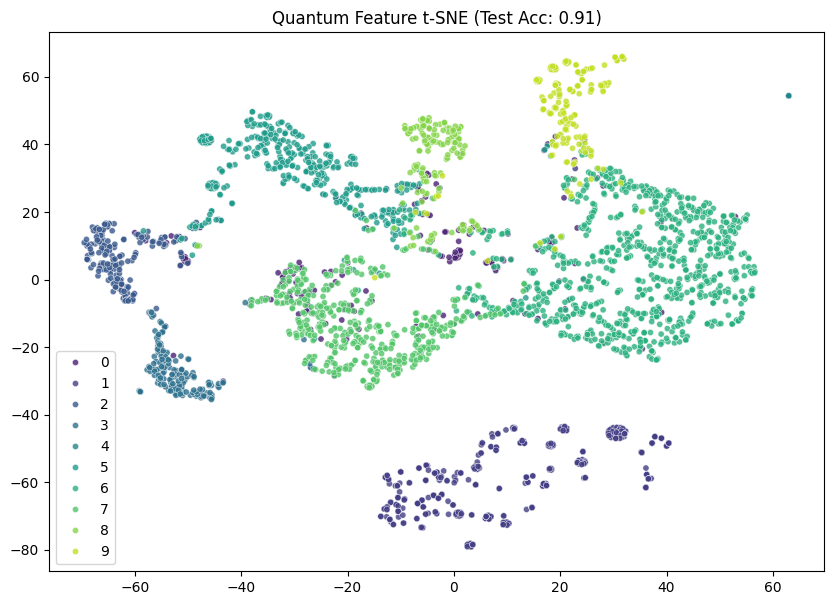

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm

# 1. DEFINE BUILDING BLOCKS (Ensuring parameters like drop_path exist)
# ─────────────────────────────────────────────────────────────────────

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4), bias=False),
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        scale = self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)
        return x * scale

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.20, drop_path=0.10):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se = SEBlock(out_ch)
        self.drop_path_rate = drop_path
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv_block(x)
        out = self.se(out)
        if self.training and self.drop_path_rate > 0:
            keep_prob = 1 - self.drop_path_rate
            random_tensor = (torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep_prob).float()
            out = out * random_tensor / keep_prob
        return self.relu(out + self.skip(x))

class QuantumBridge(nn.Module):
    def __init__(self, in_features, n_qubits):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.LayerNorm(32),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(32, n_qubits * 2)
        )
        self.angle_scale = nn.Parameter(torch.ones(n_qubits * 2) * torch.pi)
        self.angle_bias  = nn.Parameter(torch.zeros(n_qubits * 2))

    def forward(self, x):
        x = self.project(x)
        return self.angle_scale * torch.sigmoid(x) + self.angle_bias

# 2. DEFINE MAIN MODEL
# ─────────────────────────────────────────────────────────────────────

class HybridResNet(nn.Module):
    def __init__(self, n_qubits, q_out_dim, num_classes, dropout=0.35):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.stage1 = nn.Sequential(
            ResBlock(16, 16, drop_path=0.10),
            ResBlock(16, 16, drop_path=0.10)
        )
        self.stage2 = nn.Sequential(
            ResBlock(16, 32, stride=2, drop_path=0.15),
            ResBlock(32, 32, drop_path=0.15)
        )
        self.stage3 = nn.Sequential(
            ResBlock(32, 64, stride=2, drop_path=0.20),
            ResBlock(64, 64, drop_path=0.20)
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.bridge = QuantumBridge(64, n_qubits)
        self.q_layer = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(q_out_dim, q_out_dim * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(q_out_dim * 2, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x).view(x.size(0), -1)
        x = self.bridge(x)
        q_features = self.q_layer(x)
        logits = self.classifier(q_features)
        return q_features, logits

# 3. INITIALIZE AND TEST
# ─────────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_model = HybridResNet(n_qubits, q_out_dim, num_classes).to(device)

checkpoint = torch.load("hybrid_resnet_v3.pth", map_location=device)
test_model.load_state_dict(checkpoint['model_state_dict'])
test_model.eval()

all_preds, all_labels, all_features = [], [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        features, logits = test_model(inputs)
        all_preds.extend(torch.argmax(logits, 1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_features.extend(features.cpu().numpy())

# 4. RESULTS & t-SNE
# ─────────────────────────────────────────────────────────────────────

acc = accuracy_score(all_labels, all_preds)
print(f"\n🚀 Test Accuracy: {acc:.4f}")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

print("Generating t-SNE Plot...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings = tsne.fit_transform(np.array(all_features))

plt.figure(figsize=(10, 7))
sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], 
                hue=[test_dataset.classes[i] for i in all_labels], 
                palette='viridis', s=20, alpha=0.8)
plt.title(f"Quantum Feature t-SNE (Test Acc: {acc:.2f})")
plt.show()